SCALCS is designed to calculate and display variuos properties of ion channels as described in several papers (see references in SCALCS main page).

##### Some general settings

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
from samples import samples
from scalcs import scalcslib as scl

##### Define a mechanism

First, all calculations here require to specify a mechanism and give values for the rate constants (i.e. to define the $Q$ matrix).  Different ways to do that are shown elsehere (... when ready ...).  
In this notebook a mechanism used as the numerical example by Colquhoun & Hawkes 1982 is loaded from DCPYPS. 

In [3]:
demomec = samples.CH82()
print(demomec)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16


Define temporal resolution, $t_{res}$, for current calculations.

In [4]:
tres = 0.0001  # resolution in seconds

Set agonist concentration:

In [5]:
conc = 100e-9    # 100 nM
demomec.set_eff('c', conc)

Calculate and display equilibrium occupancies and lifetime of states.

In [6]:
dwells = scl.DwellsPDFDisplay(demomec, tres)
print(dwells.ideal.print_DC_table)


| Open     |   Equilibrium |   Mean lifetime | Mean latency (ms)   |
| states   |     occupancy |            (ms) | to next shutting    |
|          |               |                 | given start         |
|          |               |                 | in this state       |
|----------+---------------+-----------------+---------------------|
| Subset A |      0.001887 |        1.876543 |                     |
| 1        |      0.000025 |        0.327869 | 0.3606199517968569  |
| 2        |      0.001862 |        1.997337 | 1.997817059608271   |

| Shut     |   Equilibrium |   Mean lifetime | Mean latency (ms)   |
| states   |     occupancy |            (ms) | to next opening     |
|          |               |                 | given start         |
|          |               |                 | in this state       |
|----------+---------------+-----------------+---------------------|
| Subset B |      0.005027 |       0.459705  | -                   |
| 3        |      0.004965 |    

##### Open and shut time distributions

Calculate ideal and asymptotic distributions for both open and shut dwell times. 

In [7]:
print(dwells.ideal.print_ideal_open_time_pdf)
print(dwells.asymptotic.print_asymptotic_open_time_pdf)
print(dwells.exact.print_exact_open_time_pdf)



Ideal open time PDF components, unconditional
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |     464.415 |        500.654 |   1.99739  |   92.7616  |
|      2 |     220.771 |       3050.01  |   0.327867 |    7.23835 |
Mean (ms) = 1.8765		SD = 1.9738		SD/mean = 1.0518



ASYMPTOTIC OPEN TIME DISTRIBUTION
|   Term |   Rate (1/sec) |   tau (ms) |   Area (%) |   Area renormalised for t=0 to inf |
|--------+----------------+------------+------------+------------------------------------|
|      1 |       3045.29  |   0.328376 |    15.0747 |                            19.1474 |
|      2 |        162.929 |   6.13763  |    84.9204 |                            80.8526 |
Apparent mean open time (ms): 5.5616


EXACT OPEN TIME DISTRIBUTION
|     Eigenvalue |     g00(m) |     g10(m) |        g11(m) |
|----------------+------------+------------+---------------|
|     6.0678e-14 |   0.379833 |   0.753

Display open time distribution:

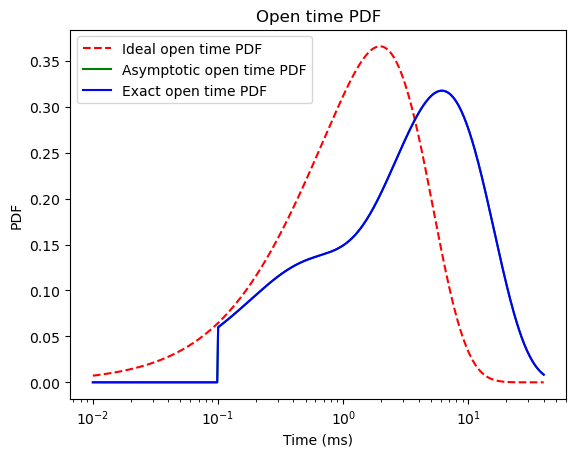

In [8]:
dwells.plot_open_time_pdf()

Print shut time distribution:

In [9]:
# Print shut time pdf's

print(dwells.ideal.print_ideal_shut_time_pdf)
print(dwells.asymptotic.print_asymptotic_shut_time_pdf)
print(dwells.exact.print_exact_shut_time_pdf)



Ideal shut time PDF components, unconditional
|   Term |     Amplitude |   Rate (1/sec) |     tau (ms) |   Area (%) |
|--------+---------------+----------------+--------------+------------|
|      1 |     0.0691263 |       0.263895 | 3789.38      |  26.1946   |
|      2 |    17.2607    |    2062.93     |    0.484747  |   0.836704 |
|      3 | 13872.7       |   19011.8      |    0.0525989 |  72.9687   |
Mean (ms) = 992.65		SD = 2556.8		SD/mean = 2.5758



ASYMPTOTIC SHUT TIME DISTRIBUTION
|   Term |   Rate (1/sec) |     tau (ms) |   Area (%) |   Area renormalised for t=0 to inf |
|--------+----------------+--------------+------------+------------------------------------|
|      1 |   17090.2      |    0.0585131 |   28.5815  |                          69.1561   |
|      2 |    2058.08     |    0.485889  |    1.67311 |                           0.900398 |
|      3 |       0.243565 | 4105.67      |   68.3542  |                          29.9435   |
Apparent mean shut time (ms): 2806.7


E

Plot shut time distribution:

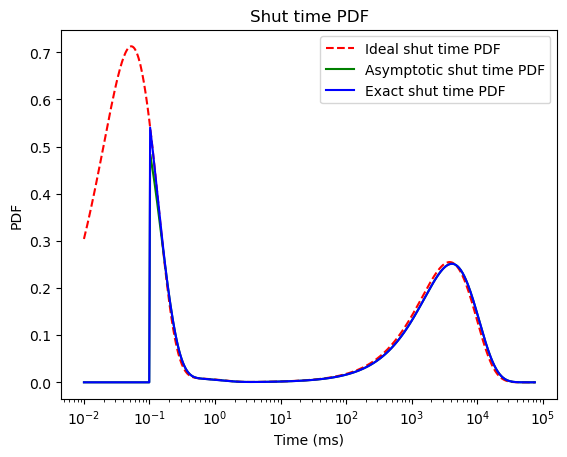

In [10]:
dwells.plot_shut_time_pdf()

Display subset time pdf:

Ideal pdf- red dashed line.
Subset life time pdf- blue solid line.


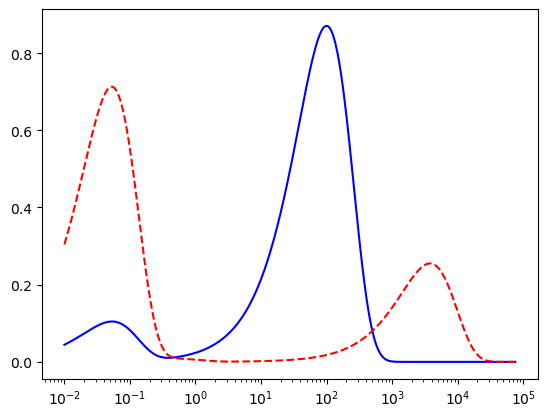

In [11]:
state1 = 3
state2 = 4
t, ipdf, spdf = scl.subset_time_pdf(demomec, tres, state1, state2)
plt.semilogx(t, spdf, 'b-', t, ipdf, 'r--')
print('Ideal pdf- red dashed line.\nSubset life time pdf- blue solid line.')